# Optimizing Train Services: Predictive Modeling and Capacity Planning Amidst COVID-19 Dynamics

This notebook performs **Exploratory Data Analysis (EDA)** on a rail ridership dataset spanning 2019–2022.
The goal is to understand ridership patterns, the impact of COVID-19, and key features for predictive modeling.

## Analysis Pipeline
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Data Understanding](#2-data-understanding)
3. [Target Analysis — Ridership Distribution](#3-target-analysis)
4. [Time Analysis](#4-time-analysis)
5. [Categorical Analysis](#5-categorical-analysis)
6. [Correlation Analysis](#6-correlation-analysis)
7. [EDA Conclusion](#7-eda-conclusion)

---
## 1. Setup & Data Loading

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

# Global plot style
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.dpi'] = 100

# Month name → number mapping (reused throughout the notebook)
MONTH_MAPPING = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

c:\Users\R.A.B\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


In [2]:
# Load the dataset
df = pd.read_csv('../data/Ridership.csv')

# Parse a proper date column from Year + Month + Day
# NOTE: original code had Day and Month swapped — fixed here
df['date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].map(MONTH_MAPPING).astype(str) + '-' +
    df['Day'].astype(str)
)

# Add numeric month column (used in correlation analysis)
df['Month_Num'] = df['Month'].map(MONTH_MAPPING)

df.head(10)

,Year,Month,Day,Week Number,Corridor,Workday,Station,Period,Ridership,N_trains,Covid19,date,Month_Num
0,2019,January,1,1,Corridor_1,n,Station_1,Weekend/Holiday,174,3,0,2019-01-01,1
1,2019,January,1,1,Corridor_1,n,Station_2,Weekend/Holiday,378,10,0,2019-01-01,1
2,2019,January,1,1,Corridor_1,n,Station_3,Weekend/Holiday,599,12,0,2019-01-01,1
3,2019,January,1,1,Corridor_2,n,Station_4,Weekend/Holiday,2759,35,0,2019-01-01,1
4,2019,January,1,1,Corridor_2,n,Station_5,Weekend/Holiday,2629,36,0,2019-01-01,1
5,2019,January,1,1,Corridor_2,n,Station_3,Weekend/Holiday,27,1,0,2019-01-01,1
6,2019,January,1,1,Corridor_3,n,Station_4,Weekend/Holiday,3321,35,0,2019-01-01,1
7,2019,January,1,1,Corridor_3,n,Station_5,Weekend/Holiday,3721,36,0,2019-01-01,1
8,2019,January,1,1,Corridor_3,n,Station_3,Weekend/Holiday,17,1,0,2019-01-01,1
9,2019,January,2,1,Corridor_1,y,Station_1,AM Peak,3519,6,0,2019-01-02,1


---
## 2. Data Understanding

### 2.1 Dataset Overview

In [3]:
# Schema and null-value check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64369 entries, 0 to 64368
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         64369 non-null  int64         
 1   Month        64369 non-null  object        
 2   Day          64369 non-null  int64         
 3   Week Number  64369 non-null  int64         
 4   Corridor     64369 non-null  object        
 5   Workday      64369 non-null  object        
 6   Station      64369 non-null  object        
 7   Period       64369 non-null  object        
 8   Ridership    64369 non-null  int64         
 9   N_trains     64369 non-null  int64         
 10  Covid19      64369 non-null  int64         
 11  date         64369 non-null  datetime64[ns]
 12  Month_Num    64369 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 6.4+ MB


The dataset contains **64,369 observations** with **11 features** describing rail ridership across temporal, spatial, and operational dimensions.
All columns are complete with **no missing values**, and the data includes both **numerical (6)** and **categorical (5)** variables.

| Column | Type | Description |
|--------|------|-------------|
| `Year` | int | Calendar year (2019–2022) |
| `Month` | str | Calendar month name |
| `Day` | int | Day of the month |
| `Week Number` | int | ISO week number |
| `Corridor` | str | Train route corridor (7 unique) |
| `Workday` | str | `y` = workday, `n` = non-workday |
| `Station` | str | Station identifier (45 unique) |
| `Period` | str | Time-of-day segment (5 unique) |
| `Ridership` | int | **Target variable** — number of passengers |
| `N_trains` | int | Number of trains deployed |
| `Covid19` | int | Binary flag: 1 = pandemic period, 0 = pre-pandemic |

### 2.2 Duplicate Check

In [4]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')

Duplicate rows: 0


There are **no duplicated rows** — the dataset is clean and ready for analysis.

### 2.3 Numerical Features Summary

In [5]:
df.describe()

,Year,Day,Week Number,Ridership,N_trains,Covid19,date,Month_Num
count,64369.000000,64369.000000,64369.000000,64369.000000,64369.000000,64369.000000,64369,64369.000000
mean,2020.461853,15.790598,26.954186,1091.399462,5.618248,0.475974,2020-12-19 21:44:33.951747072,6.609859
min,2019.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2019-01-01 00:00:00,1.000000
25%,2019.000000,8.000000,13.000000,108.000000,2.000000,0.000000,2019-11-25 00:00:00,3.000000
50%,2020.000000,16.000000,27.000000,368.000000,4.000000,0.000000,2020-12-16 00:00:00,7.000000
75%,2022.000000,23.000000,41.000000,1135.000000,6.000000,1.000000,2022-01-03 00:00:00,10.000000
max,2022.000000,31.000000,53.000000,26798.000000,50.000000,1.000000,2022-12-31 00:00:00,12.000000
std,1.143510,8.750175,15.400862,1863.907282,5.955504,0.499426,NaN,3.533128


**Key observations from descriptive statistics:**

- **`Ridership`** is highly right-skewed (mean = 1,091 vs. median = 368; max = 26,798), indicating strong peak effects at a subset of stations and corridors.
- **`N_trains`** ranges from 0 to 50, with most values at lower levels (median = 4), reflecting uneven service allocation.
- **`Covid19`** has a mean of ≈ 0.48, meaning roughly half the observations fall within the pandemic period — useful for balanced comparative analysis.
- Temporal columns (`Year`, `Day`, `Week Number`) are well distributed, suitable for capturing seasonal and weekly patterns.

### 2.4 Categorical Features Summary

In [6]:
cat_features = ['Corridor', 'Workday', 'Station', 'Period']

for col in cat_features:
    unique_vals = df[col].unique()
    print(f'{col} ({len(unique_vals)} unique values):')
    print(unique_vals)
    print()

Corridor (7 unique values):
['Corridor_1' 'Corridor_2' 'Corridor_3' 'Corridor_4' 'Corridor_5'
 'Corridor_6' 'Corridor_7']

Workday (2 unique values):
['n' 'y']

Station (45 unique values):
['Station_1' 'Station_2' 'Station_3' 'Station_4' 'Station_5' 'Station_6'
 'Station_7' 'Station_8' 'Station_9' 'Station_10' 'Station_11'
 'Station_12' 'Station_13' 'Station_14' 'Station_15' 'Station_16'
 'Station_17' 'Station_18' 'Station_19' 'Station_20' 'Station_21'
 'Station_22' 'Station_23' 'Station_24' 'Station_25' 'Station_26'
 'Station_27' 'Station_28' 'Station_29' 'Station_30' 'Station_31'
 'Station_32' 'Station_33' 'Station_34' 'Station_35' 'Station_36'
 'Station_37' 'Station_38' 'Station_39' 'Station_40' 'Station_41'
 'Station_42' 'Station_43' 'Station_44' 'Station_45']

Period (5 unique values):
['Weekend/Holiday' 'AM Peak' 'Midday' 'Evening' 'PM Peak']



Categorical variables and their roles:

- **`Corridor`** — 7 categories (`Corridor_1`–`Corridor_7`): captures different train routes.
- **`Workday`** — Binary (`y` / `n`): distinguishes weekdays from weekends and holidays.
- **`Station`** — 45 unique stations: enables location-specific ridership analysis.
- **`Period`** — 5 time-of-day segments (`AM Peak`, `Midday`, `PM Peak`, `Evening`, `Weekend/Holiday`).

These variables are essential for group-based aggregation, ridership comparison, and feature encoding in predictive modeling.

---
## 3. Target Analysis

### 3.1 Distribution of Ridership

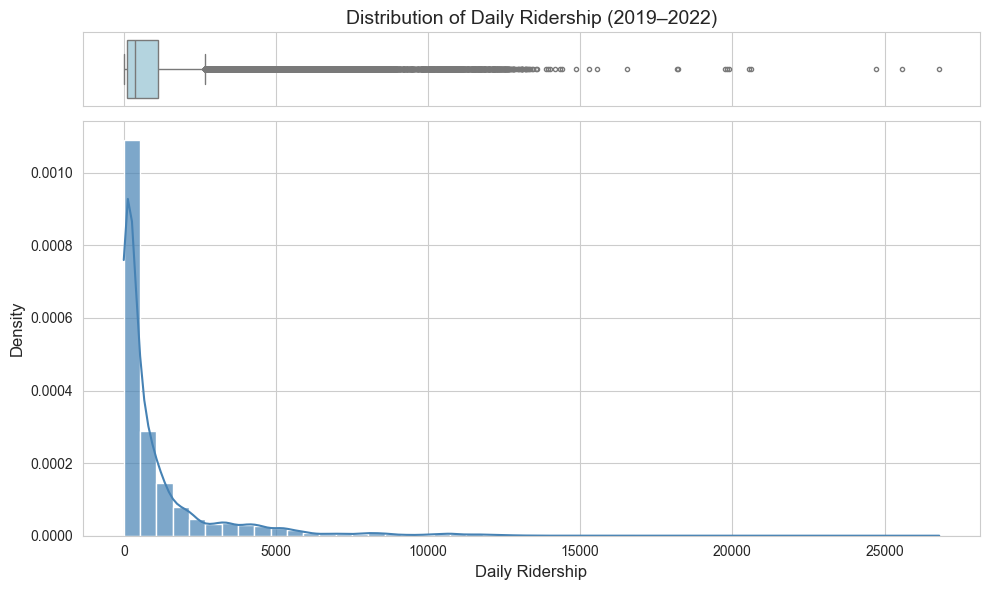

In [7]:
data = df['Ridership']

# Combined boxplot + histogram to show shape and outliers together
fig, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True,
    gridspec_kw={'height_ratios': (0.15, 0.85)},
    figsize=(10, 6)
)

# Boxplot — highlights median, IQR, and outliers
sns.boxplot(x=data, ax=ax_box, color='lightblue', fliersize=3)
ax_box.set(xlabel='')  # Remove duplicate x-label
ax_box.set_title('Distribution of Daily Ridership (2019–2022)', fontsize=14)

# Histogram + KDE — shows density shape
sns.histplot(data, bins=50, kde=True, ax=ax_hist,
             color='steelblue', alpha=0.7, stat='density')
ax_hist.set_xlabel('Daily Ridership', fontsize=12)
ax_hist.set_ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

**Key observations:**
- The distribution is **strongly right-skewed** — most records cluster near zero/low values, but a long tail reaches up to ~26,000.
- The boxplot reveals numerous high-value **outliers**, concentrated at high-demand stations during peak periods.
- This skewness motivates careful **outlier treatment** and possible **log transformation** before modeling.

### 3.2 Daily Ridership Over Time

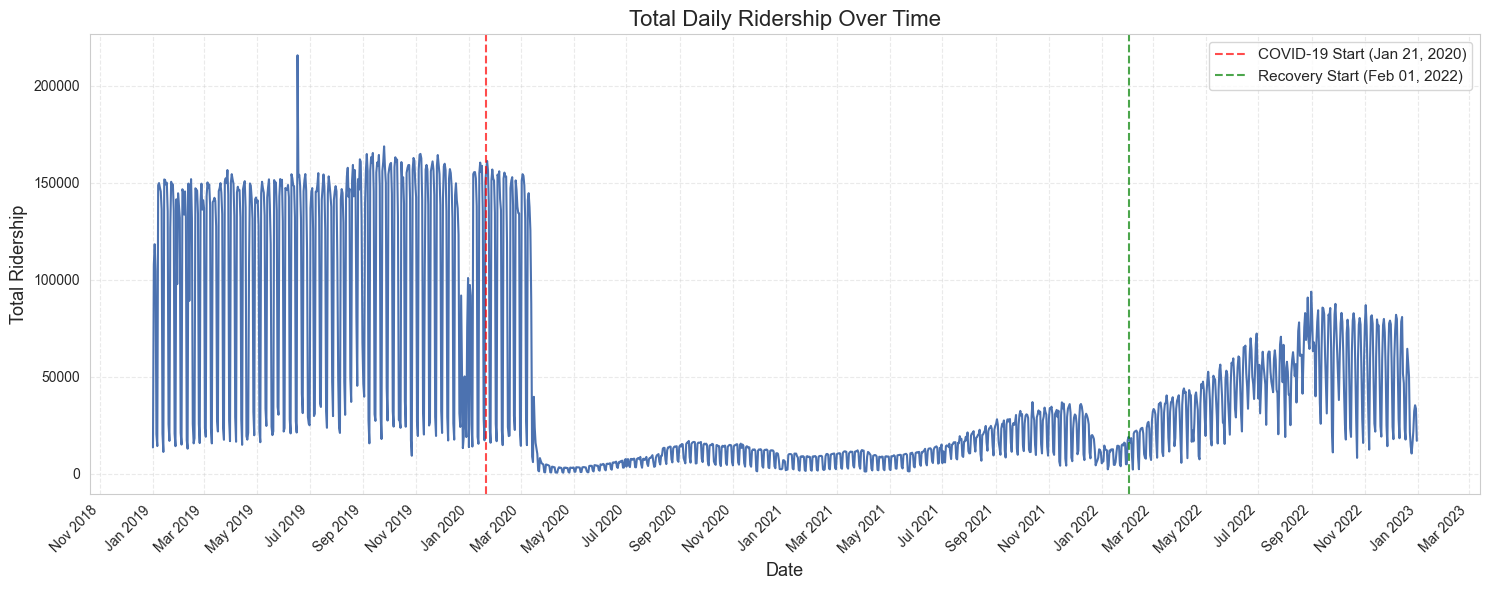

In [8]:
# Aggregate total ridership per date across all stations/corridors
daily_ridership = df.groupby('date')['Ridership'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(daily_ridership['date'], daily_ridership['Ridership'],
        color='#4C72B0', linewidth=1.5)

# Annotate COVID-19 start
covid_start = pd.Timestamp('2020-01-21')
ax.axvline(covid_start, color='red', linestyle='--', alpha=0.7, label='COVID-19 Start (Jan 21, 2020)')

# Annotate recovery start
recovery_start = pd.Timestamp('2022-02-01')
ax.axvline(recovery_start, color='green', linestyle='--', alpha=0.7, label='Recovery Start (Feb 01, 2022)')

ax.set_title('Total Daily Ridership Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Total Ridership', fontsize=13)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Pandemic Impact & Recovery:**

- **Pre-pandemic (2019 – Jan 2020):** Stable ridership with clear seasonal patterns.
- **COVID-19 drop (from Jan 21, 2020):** Ridership collapsed due to lockdowns, remote work policies, and travel restrictions.
- **Recovery phase (from Feb 1, 2022):** Ridership trended upward as restrictions lifted and public confidence returned — though the recovery wasn't instantaneous.

### 3.3 Ridership by COVID-19 Status

In [9]:
# Descriptive stats split by pandemic flag
df.groupby('Covid19')['Ridership'].describe()

,count,mean,std,min,25%,50%,75%,max
Covid19,,,,,,,,
0,33731.0,1675.799976,2236.488198,0.0,284.0,830.0,2050.00,26798.0
1,30638.0,448.001926,1001.155660,0.0,52.0,175.0,414.75,12514.0


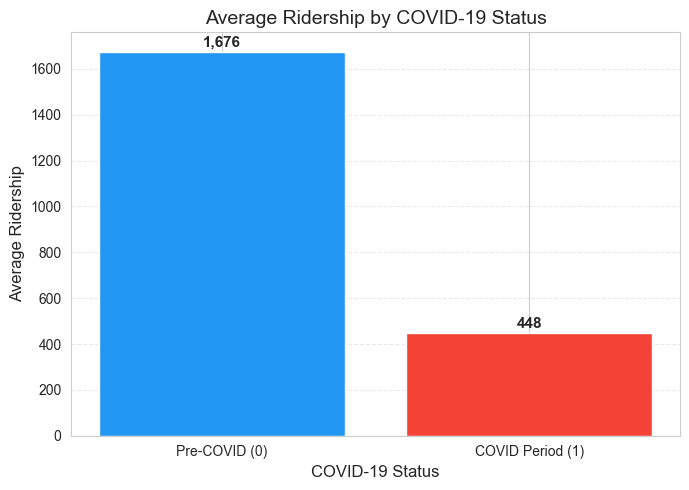

In [10]:
covid_avg = df.groupby('Covid19').agg(mean_ridership=('Ridership', 'mean')).reset_index()
covid_avg['Label'] = covid_avg['Covid19'].map({0: 'Pre-COVID (0)', 1: 'COVID Period (1)'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(covid_avg['Label'], covid_avg['mean_ridership'], color=['#2196F3', '#F44336'])

# Add value labels on top of bars
for bar, val in zip(bars, covid_avg['mean_ridership']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Ridership by COVID-19 Status', fontsize=14)
ax.set_xlabel('COVID-19 Status', fontsize=12)
ax.set_ylabel('Average Ridership', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Key Insight:**

| Period | Average Ridership | % of Pre-COVID |
|--------|:-----------------:|:--------------:|
| Pre-COVID (0) | ~1,676 | 100% |
| COVID Period (1) | ~448 | ~27% |

Average ridership during the pandemic period was only **~27%** of pre-COVID levels — a dramatic structural shift.
The `Covid19` flag will be an important predictor in any model built on this data.

---
## 4. Time Analysis

### 4.1 Ridership by Workday Status

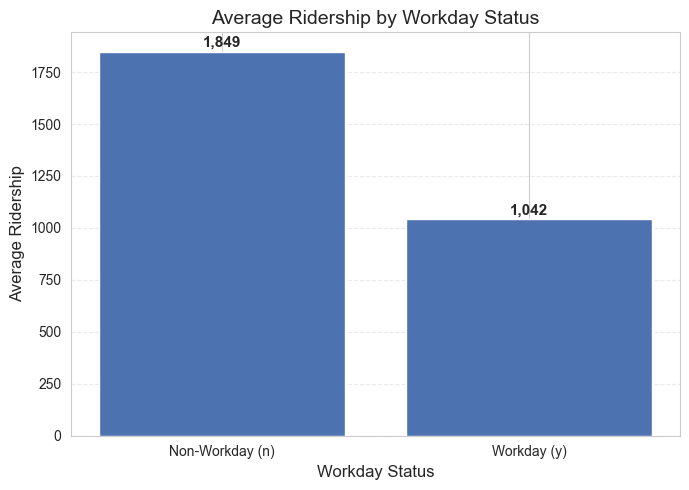

In [11]:
workday_avg = df.groupby('Workday').agg(mean_ridership=('Ridership', 'mean')).reset_index()
workday_avg['Label'] = workday_avg['Workday'].map({'y': 'Workday (y)', 'n': 'Non-Workday (n)'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(workday_avg['Label'], workday_avg['mean_ridership'], color='#4C72B0')

for bar, val in zip(bars, workday_avg['mean_ridership']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Ridership by Workday Status', fontsize=14)
ax.set_xlabel('Workday Status', fontsize=12)
ax.set_ylabel('Average Ridership', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Key Insight:**

| Workday Status | Average Ridership |
|----------------|:-----------------:|
| Non-Workday (n) | ~1,849 |
| Workday (y) | ~1,042 |

Non-workdays show **~77% higher** average ridership than workdays. Possible explanations:
- **Leisure & recreational travel** drives higher weekend ridership.
- **Pandemic-era work-from-home** reduced weekday commuting, amplifying the gap.
- Weekend/holiday **fare policies** or event-driven travel may also contribute.

### 4.2 Monthly Ridership by Year

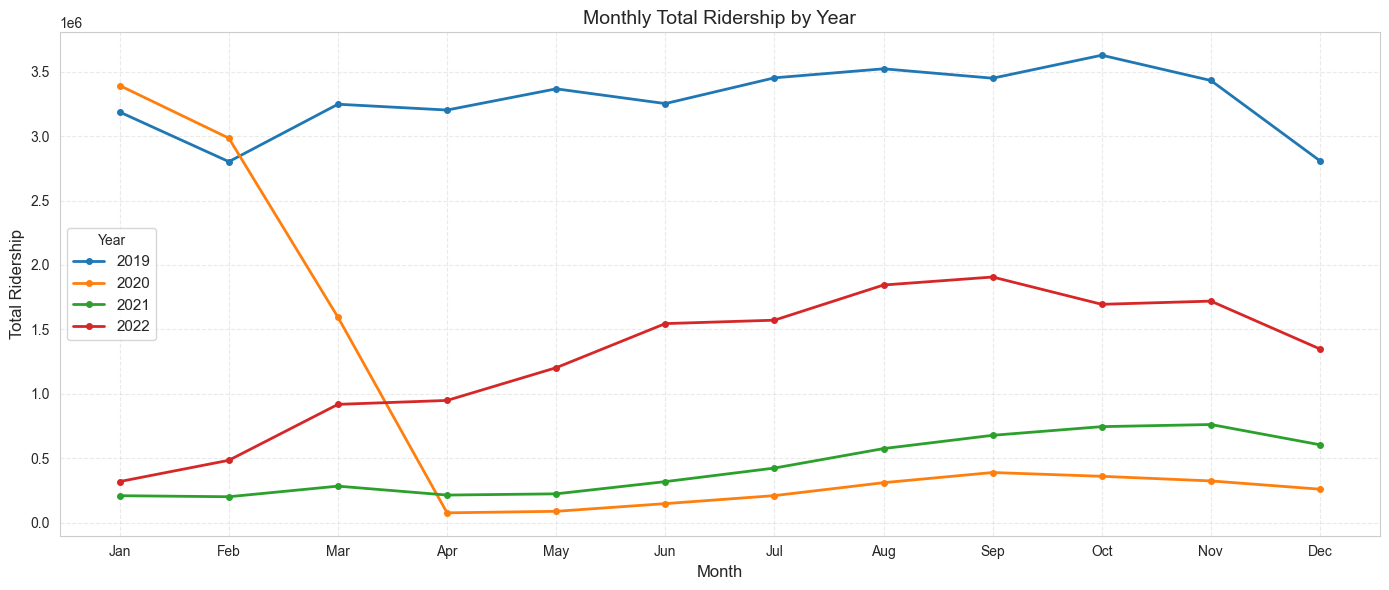

In [12]:
# Aggregate monthly ridership totals, then sort by calendar month order
monthly = (
    df.groupby(['Year', 'Month', 'Month_Num'])['Ridership']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month_Num'])
)

fig, ax = plt.subplots(figsize=(14, 6))

for year in sorted(monthly['Year'].unique()):
    yr_data = monthly[monthly['Year'] == year]
    ax.plot(yr_data['Month_Num'], yr_data['Ridership'],
            marker='o', markersize=4, linewidth=2, label=str(year))

ax.set_title('Monthly Total Ridership by Year', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Ridership', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Year-over-Year Comparison:**

| Year | Pattern | Notes |
|------|---------|-------|
| **2019** | Stable (~2.8M–3.6M) | Peaks in Jul–Oct (summer/fall) |
| **2020** | Sharp collapse from March | Near-zero by April; slight uptick Q4 |
| **2021** | Gradual recovery | Starting very low; modest rise through year |
| **2022** | Strong recovery | Significant bounce after February; summer approaches 2019 levels |

**Seasonality** is visible in 2019 and re-emerges in 2022, with warmer months consistently showing higher ridership.

### 4.3 Ridership by Time Period Across Years

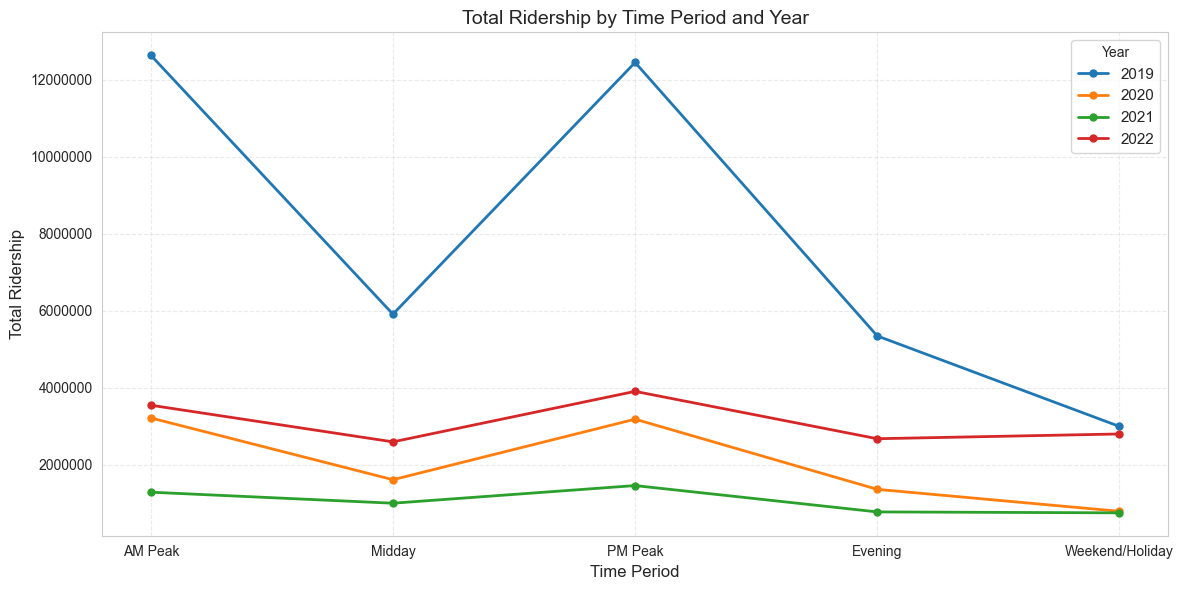

In [13]:
# Define the canonical ordering of time periods
PERIOD_ORDER = ['AM Peak', 'Midday', 'PM Peak', 'Evening', 'Weekend/Holiday']

period_year = (
    df.groupby(['Year', 'Period'])['Ridership']
    .sum()
    .reset_index()
)
period_year['Period'] = pd.Categorical(
    period_year['Period'], categories=PERIOD_ORDER, ordered=True
)
period_year = period_year.sort_values(['Year', 'Period'])

fig, ax = plt.subplots(figsize=(12, 6))

for year in sorted(period_year['Year'].unique()):
    yr_data = period_year[period_year['Year'] == year]
    ax.plot(yr_data['Period'].astype(str), yr_data['Ridership'],
            marker='o', markersize=5, linewidth=2, label=str(year))

ax.set_title('Total Ridership by Time Period and Year', fontsize=14)
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Total Ridership', fontsize=12)
ax.ticklabel_format(style='plain', axis='y')
ax.legend(title='Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Key Insights:**

- **Peak hours dominate** in all years: AM Peak and PM Peak consistently show the highest ridership — confirming strong commuter-driven demand.
- **Midday and Evening** are consistently lower, suggesting off-peak periods are less utilized.
- **2019** is the clear high-water mark across all periods (pre-pandemic baseline).
- **2020–2021** show a dramatic drop across all time periods, with PM Peak taking the largest absolute hit.
- **2022** shows recovery but remains below 2019 levels — indicating partial, not full, return to pre-pandemic behavior.

---
## 5. Categorical Analysis

### 5.1 Ridership Distribution by Station

In [14]:
station_stats = (
    df.groupby('Station')['Ridership']
    .describe()
    .sort_values('mean', ascending=False)
)
station_stats

,count,mean,std,min,25%,50%,75%,max
Station,,,,,,,,
Station_43,264.0,2331.515152,1606.471736,464.0,969.25,2023.5,3026.00,6131.0
Station_5,4362.0,2067.290463,2730.188482,37.0,428.25,973.0,2474.75,14005.0
Station_19,2015.0,1812.623325,2541.336225,6.0,144.00,470.0,2257.00,9102.0
Station_17,1002.0,1629.751497,1676.407857,51.0,218.25,830.0,3535.00,5762.0
Station_3,23104.0,1421.473251,2272.927127,0.0,160.00,496.0,1489.25,26798.0
Station_4,4625.0,1418.662703,1676.557906,0.0,344.00,772.0,1922.00,25587.0
Station_12,380.0,1088.394737,517.523754,3.0,857.25,1314.0,1424.00,3595.0
Station_21,2102.0,1068.854900,1326.022727,0.0,104.25,301.5,1911.00,5269.0
Station_1,2551.0,998.732262,1511.209614,0.0,98.50,396.0,925.00,6130.0


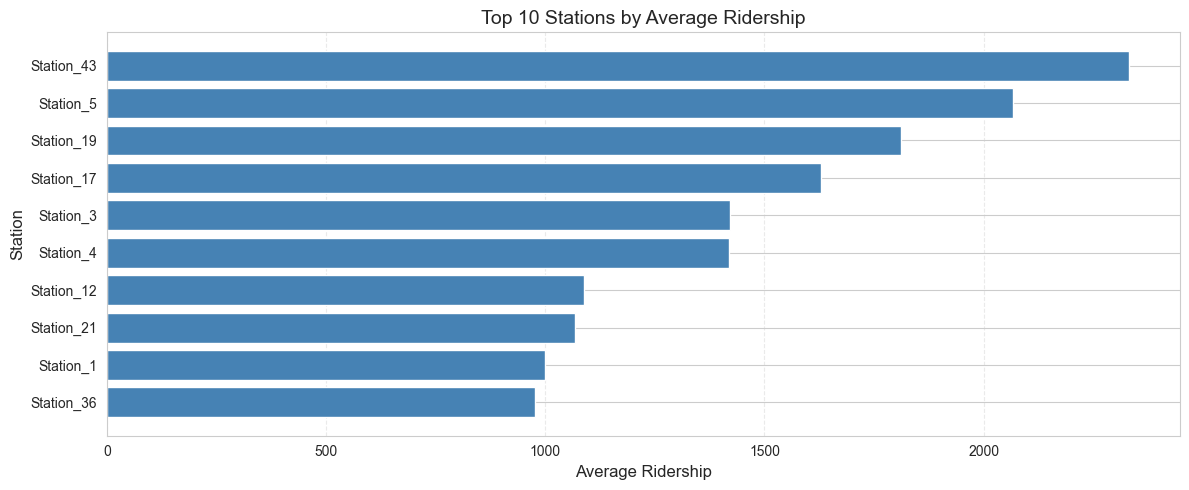

In [15]:
# Highlight top-10 and bottom-5 stations by mean ridership
top_stations = station_stats.head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_stations['Station'], top_stations['mean'], color='steelblue')
ax.invert_yaxis()  # Highest mean at top
ax.set_title('Top 10 Stations by Average Ridership', fontsize=14)
ax.set_xlabel('Average Ridership', fontsize=12)
ax.set_ylabel('Station', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Station-level findings:**

- **High-demand stations** (e.g., Station_5, Station_3, Station_4, Station_19, Station_43) have both high mean ridership and large maximums.
- **Low-demand stations** (e.g., Station_11, Station_2, Station_18) consistently show low average ridership.
- Several stations have **very small sample sizes** (count ≤ 10), limiting statistical reliability — these may be merged into an `Other` category during preprocessing.
- The wide gap between median and maximum at major stations confirms a **highly skewed, peak-driven distribution**.

### 5.2 Ridership Distribution by Corridor

In [16]:
corridor_stats = (
    df.groupby('Corridor')['Ridership']
    .describe()
    .sort_values('mean', ascending=False)
)
corridor_stats

,count,mean,std,min,25%,50%,75%,max
Corridor,,,,,,,,
Corridor_2,9939.0,1819.185129,2512.683510,6.0,332.0,849.0,2143.00,14005.0
Corridor_5,4034.0,1773.547595,2608.529859,0.0,148.0,467.5,2079.75,9823.0
Corridor_3,15739.0,1505.349641,2166.208766,0.0,318.5,750.0,1679.50,26798.0
Corridor_6,3963.0,693.204391,1019.739570,0.0,45.0,160.0,815.00,3694.0
Corridor_1,10039.0,640.466381,1172.738012,0.0,59.0,236.0,606.00,6130.0
Corridor_7,8229.0,613.853810,1096.784355,0.0,54.0,157.0,502.00,5674.0
Corridor_4,12426.0,571.061323,1062.068349,0.0,60.0,177.0,507.00,6882.0


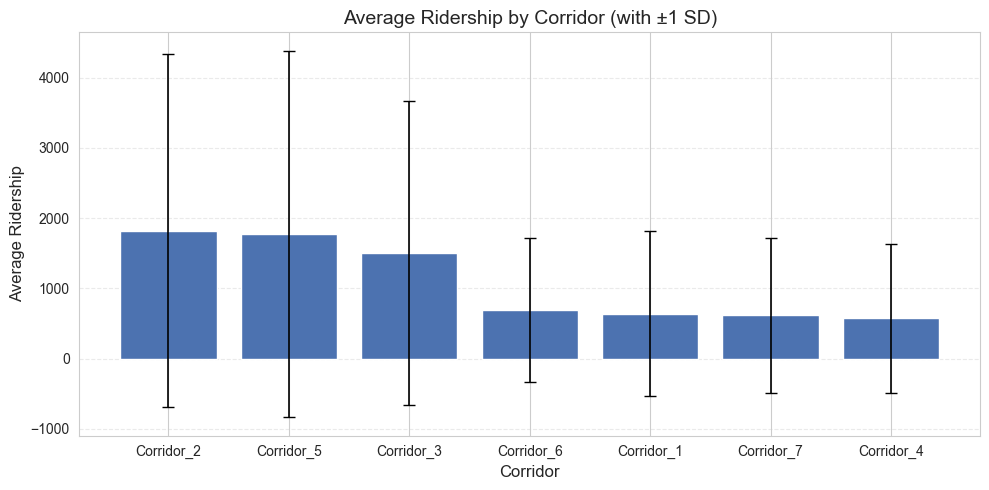

In [17]:
corridor_avg = corridor_stats[['mean', 'std']].reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(corridor_avg['Corridor'], corridor_avg['mean'], color='#4C72B0')
ax.errorbar(
    corridor_avg['Corridor'], corridor_avg['mean'],
    yerr=corridor_avg['std'], fmt='none', color='black', capsize=4, linewidth=1.2
)

ax.set_title('Average Ridership by Corridor (with ±1 SD)', fontsize=14)
ax.set_xlabel('Corridor', fontsize=12)
ax.set_ylabel('Average Ridership', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Corridor-level findings:**

- **Corridor_2** and **Corridor_5** show the highest average ridership (~1,800 and ~1,770 respectively) — major demand routes.
- **Corridor_3** has the highest maximum (26,798) but also high standard deviation — indicating extreme, intermittent peak loads.
- **Corridor_4**, **Corridor_6**, and **Corridor_7** exhibit lower average ridership and smaller ranges.
- Large standard deviations across most corridors indicate **high dispersion and peak-driven demand**.

---
## 6. Correlation Analysis

### 6.1 Ridership vs. Time Features

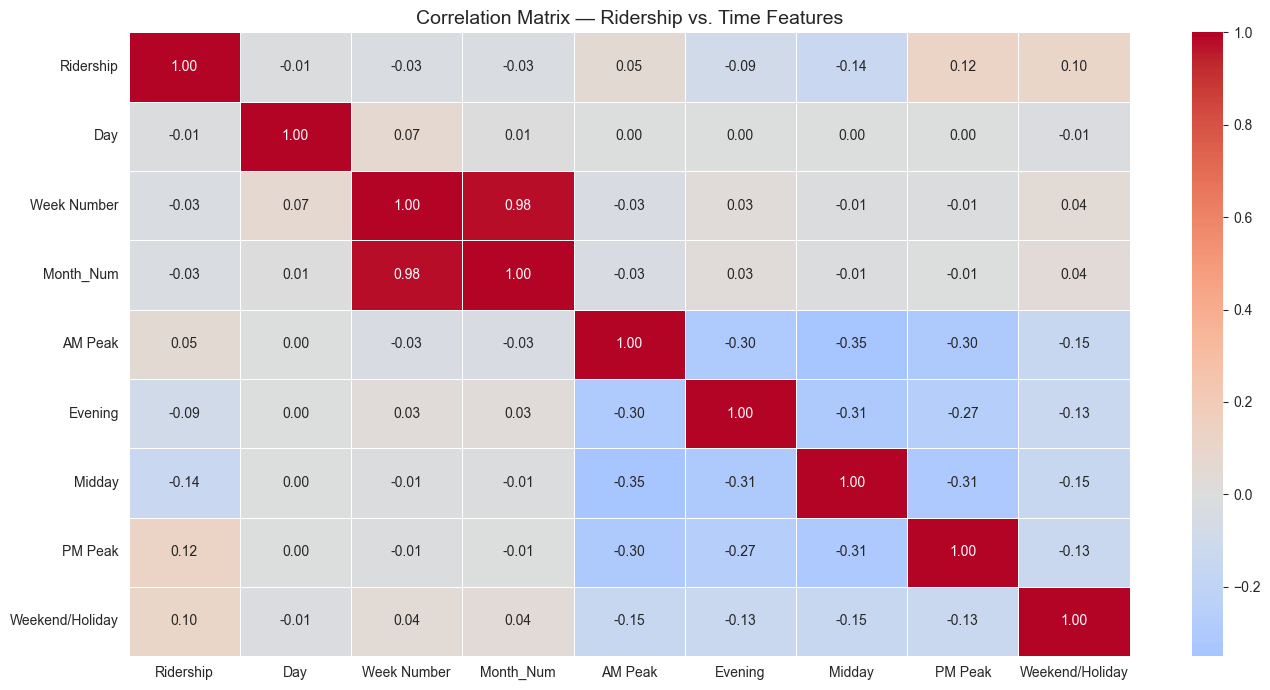

In [18]:
# One-hot encode Period for correlation (avoid multicollinearity with drop_first)
period_dummies = pd.get_dummies(df['Period'], prefix='', prefix_sep='')
df_time = pd.concat([df[['Ridership', 'Day', 'Week Number', 'Month_Num']], period_dummies], axis=1)

corr_time = df_time.corr()

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    corr_time, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Ridership vs. Time Features', fontsize=14)

plt.tight_layout()
plt.show()

**Pearson Correlation Summary — Time Features vs. Ridership:**

| Feature | r | Interpretation |
|---------|---|----------------|
| PM Peak | **+0.12** | Modest positive — afternoon commute hours perform relatively well |
| Weekend/Holiday | **+0.10** | Slight boost from leisure/event travel |
| AM Peak | **+0.05** | Very weak — morning rush less pronounced than PM |
| Day | **~0.00** | No meaningful relationship with day-of-month |
| Week Number | **-0.03** | No linear weekly trend |
| Month_Num | **-0.03** | No linear monthly/seasonal trend |
| Evening | **-0.09** | Lower ridership in evening periods |
| Midday | **-0.14** | **Strongest negative** — midday consistently lowest ridership |

**Takeaway:** Time-of-day matters more than calendar progression. Midday is the weakest period; PM Peak is the strongest. No strong linear seasonal trend exists in raw correlations — seasonal effects likely interact with `Covid19` and other features.

### 6.2 Ridership vs. COVID-19 and Corridor

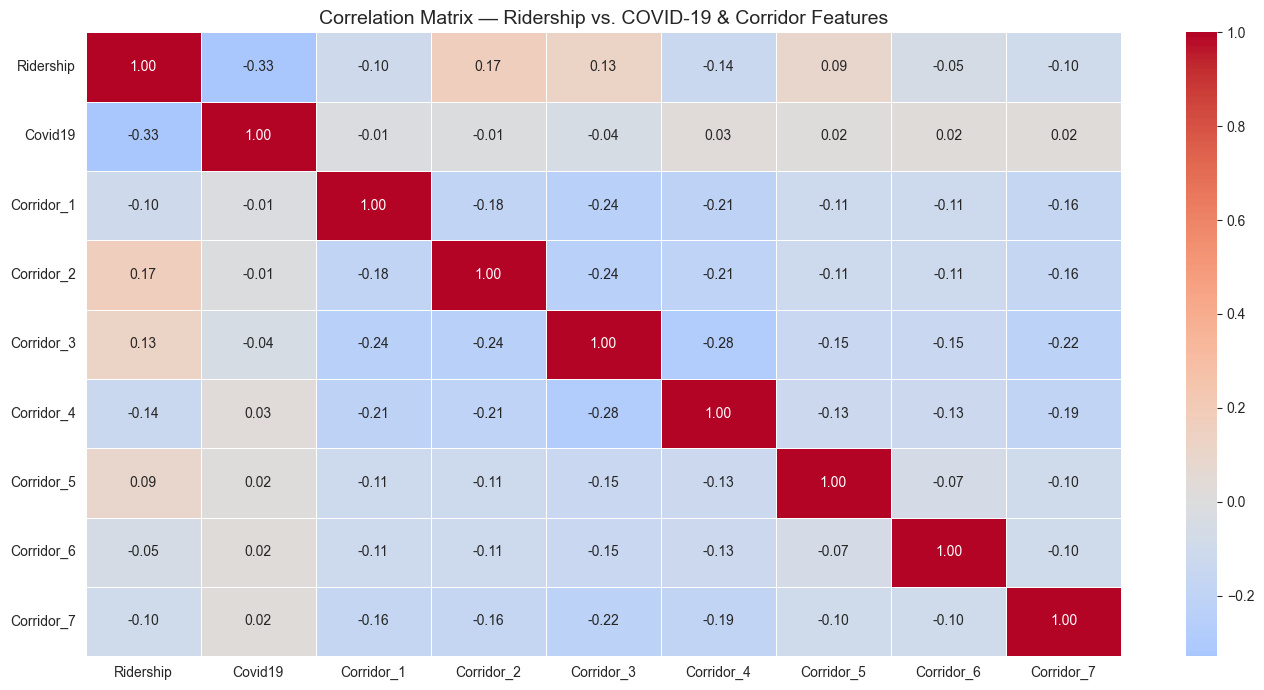

In [19]:
# One-hot encode Corridor
corridor_dummies = pd.get_dummies(df['Corridor'], prefix='', prefix_sep='')
df_corridor = pd.concat([df[['Ridership', 'Covid19']], corridor_dummies], axis=1)

corr_corridor = df_corridor.corr()

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    corr_corridor, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Ridership vs. COVID-19 & Corridor Features', fontsize=14)

plt.tight_layout()
plt.show()

**Pearson Correlation Summary — COVID-19 & Corridors vs. Ridership:**

| Feature | r | Interpretation |
|---------|---|----------------|
| Covid19 | **-0.33** | **Strongest relationship** — pandemic periods strongly reduce ridership |
| Corridor_2 | **+0.17** | Weak positive — this corridor shows relatively higher ridership |
| Corridor_3 | **+0.13** | Weak positive |
| Corridor_5 | **+0.10** | Very weak positive |
| Corridor_1 | **-0.10** | Very weak negative |
| Corridor_6 | **-0.06** | Negligible |
| Corridor_7 | **-0.10** | Very weak negative |
| Corridor_4 | **-0.14** | Weak negative |

**Takeaway:** `Covid19` is by far the strongest predictor in the linear sense (r = -0.33). Corridor effects are modest — Corridor_2 and Corridor_3 show mild positive associations, while Corridor_4 is slightly negative.

---
## 7. EDA Conclusion

The following insights should guide downstream preprocessing and modeling:

### Data Quality
- ✅ **No missing values or duplicate rows** — the dataset is clean.
- ⚠️ **Outliers exist** — extreme ridership values at high-demand stations/corridors during peak periods. Handle via IQR capping or robust modeling.

### Target Variable (`Ridership`)
- **Right-skewed** distribution (mean >> median). Consider a **log transform or PowerTransformer** before training linear models.
- Station-level heterogeneity is large — high-demand stations dominate mean calculations.

### Key Predictors
| Feature | Importance |
|---------|------------|
| `Covid19` | High — moderate negative linear correlation (r = -0.33); major structural driver |
| `Period` (time of day) | Moderate — PM Peak positive, Midday negative |
| `Corridor` | Moderate — Corridor_2 and Corridor_3 most positively associated |
| `Workday` | Moderate — non-workdays show ~77% higher average ridership |
| `Station` | High (non-linear) — large heterogeneity; target encoding recommended |
| Calendar features (`Day`, `Week`, `Month`) | Weak linear signal alone; stronger as lag/rolling features |

### Recommendations for Modeling
1. **Outlier treatment**: Cap/clip extreme ridership values using IQR bounds on the training set.
2. **Target encoding**: Encode `Station` by mean ridership (fit on train only) to capture location effects without high cardinality.
3. **Lag features**: Add lag-1, lag-7 and rolling means — this is a time-series problem and temporal autocorrelation is likely strong.
4. **Log transformation**: Apply if residuals from linear models show heteroskedasticity.
5. **COVID flag**: Always include — it's the single strongest predictor.